In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv(r"E:\Data Science by SRK\Machine_learning\project\Medical Insurance Costs Dataset\cleaned_dataset_medical_cost_insurance.csv")

In [41]:
df


,age,gender,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520
...,...,...,...,...,...,...
1332,50,1,30.970,3,0,10600.54830
1333,18,0,31.920,0,0,2205.98080
1334,18,0,36.850,0,0,1629.83350
1335,21,0,25.800,0,0,2007.94500


In [42]:
df.corr()

,age,gender,bmi,children,smoker,charges
age,1.000000,-0.019814,0.109344,0.041536,-0.025587,0.298308
gender,-0.019814,1.000000,0.046397,0.017848,0.076596,0.058044
bmi,0.109344,0.046397,1.000000,0.012755,0.003746,0.198401
children,0.041536,0.017848,0.012755,1.000000,0.007331,0.067389
smoker,-0.025587,0.076596,0.003746,0.007331,1.000000,0.787234
charges,0.298308,0.058044,0.198401,0.067389,0.787234,1.000000


In [43]:
X = df[['age', 'gender', 'bmi', 'children', 'smoker']]
y = df['charges']

# check for Random State number

In [44]:
Train = []

CV = []

for i in range(0,10):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)
    
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    ypred_train = model.predict(X_train)
    
    from sklearn.metrics import r2_score
    Train.append(r2_score(y_train, ypred_train))
    
    from sklearn.model_selection import cross_val_score
    CV.append(cross_val_score(model, X_train, y_train, cv = 5).mean())
    
em = pd.DataFrame({"Train" : Train, "CV" : CV})
gm = em[(abs(em["Train"] - em["CV"]) <= 0.05)]
rs = gm[gm["CV"] == gm["CV"].max()].index.tolist()[0]
print("Best Random state number is : ", rs)

Best Random state number is :  9


**Train_Test_Split**

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 9)

# Modelling

In [46]:
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'charges'], dtype='object')

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model

LinearRegression()

In [48]:
model.fit(X_train, y_train)

LinearRegression()

In [49]:
X.head()

,age,gender,bmi,children,smoker
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0


In [50]:
print('coefficient : ', model.coef_)
print("===========================")
print('itercept : ', model.intercept_)

coefficient :  [  264.55942135  -121.91862701   318.35415133   411.92663743
 23988.99617568]
itercept :  -12150.175624756312


In [51]:
print(X_train.shape)
print(y_train.shape)

(1069, 5)
(1069,)


In [52]:
print(X_test.shape)
print(y_test.shape)

(268, 5)
(268,)


# Evaluation

In [53]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [54]:
# Prediction RMSE

ypred_train = model.predict(X_train)
ypred_test = model.predict(X_test)


# EVALUATION

print("Train_RMSE : ", np.sqrt(mean_squared_error(y_train, ypred_train)))
print("cv_score_RMSE", np.sqrt(abs(cross_val_score(model, X_train, y_train, cv = 5, scoring = 'neg_mean_squared_error')).mean()))
print("Test_RMSE : ", np.sqrt(mean_squared_error(y_test, ypred_test)))


Train_RMSE :  6044.636795412412
cv_score_RMSE 6095.304403802664
Test_RMSE :  6120.2261580759905


In [55]:
# Prediction R2

ypred_train = model.predict(X_train)
ypred_test = model.predict(X_test)

print("Train_R2 : ", r2_score(y_train, ypred_train))
print("CV_Score_R2", cross_val_score(model, X_train, y_train, cv = 5, scoring = 'r2').mean())
print("Test_R2 : ", r2_score(y_test, ypred_test))

Train_R2 :  0.7593597894080424
CV_Score_R2 0.7534226479389894
Test_R2 :  0.7006202214756434


In [56]:
# ALL EVALUATION IN ONE CELL

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score


# Prediction RMSE

ypred_train = model.predict(X_train)
ypred_test = model.predict(X_test)


# EVALUATION

print("Train_RMSE : ", np.sqrt(mean_squared_error(y_train, ypred_train)))
print("cv_score_RMSE", np.sqrt(abs(cross_val_score(model, X_train, y_train, cv = 5, scoring = 'neg_mean_squared_error')).mean()))
print("Test_RMSE : ", np.sqrt(mean_squared_error(y_test, ypred_test)))


print("=================================================")


# Prediction R2

ypred_train = model.predict(X_train)
ypred_test = model.predict(X_test)

print("Train_R2 : ", r2_score(y_train, ypred_train))
print("CV_Score_R2", cross_val_score(model, X_train, y_train, cv = 5, scoring = 'r2').mean())
print("Test_R2 : ", r2_score(y_test, ypred_test))

Train_RMSE :  6044.636795412412
cv_score_RMSE 6095.304403802664
Test_RMSE :  6120.2261580759905
Train_R2 :  0.7593597894080424
CV_Score_R2 0.7534226479389894
Test_R2 :  0.7006202214756434


In [57]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df,train_size = 0.8, random_state = 9)


import statsmodels.formula.api as smf
model1 = smf.ols("y_train~X_train", data= df_train).fit()  # o/p upon i/p : calculate b1,b2,b3
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                y_train   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     670.9
Date:                Mon, 10 Feb 2025   Prob (F-statistic):               0.00
Time:                        20:36:05   Log-Likelihood:                -10825.
No. Observations:                1069   AIC:                         2.166e+04
Df Residuals:                    1063   BIC:                         2.169e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.215e+04   1064.347    -11.416      0.000   -1.42e+04   -1.01e+04
X_train[0]   264.5594     13.386     19.764      0.000     238.294     290.825
X_train[1]  -121.9186    372.547     -0.327      0.744    -852.929     609.092
X_train[2]   318.3542     30.716     10.365      0.000     258.084     378.624
X_train[3]   411.9266    155.215      2.654      0.008     107.365     716.488
X_train[4]  2.399e+04    454.370     52.796      0.000    2.31e+04    2.49e+04
==============================================================================
Omnibus:                      223.989   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              516.849
Skew:                           1.138   Prob(JB):                    5.86e-113
Kurtosis:                       5.534   Cond. No.                         294.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

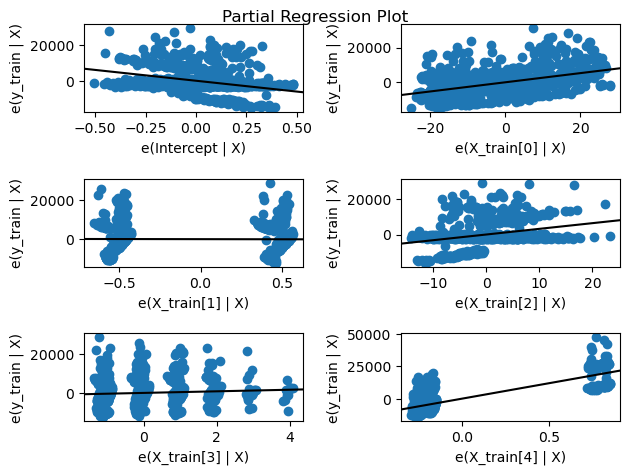

In [59]:
import statsmodels.api as sm
sm.graphics.plot_partregress_grid(model1)
plt.show()

**check influential records**

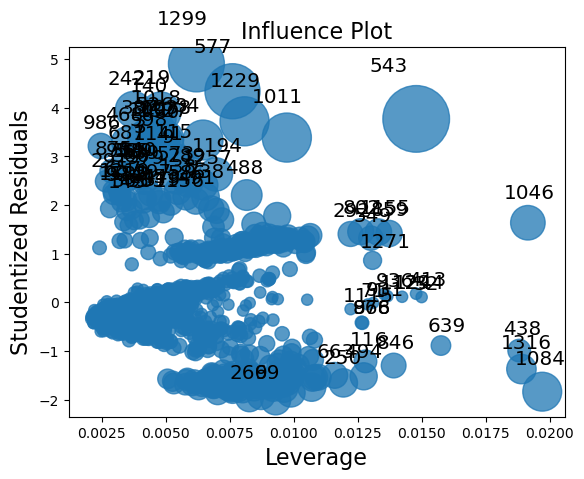

In [60]:
import statsmodels.api as sm

sm.graphics.influence_plot(model1)
plt.show()

In [61]:
df.iloc[639]

age           33.000
gender         1.000
bmi           42.400
children       5.000
smoker         0.000
charges     6666.243
Name: 639, dtype: float64

In [62]:
import statsmodels.api as sm
import pandas as pd

# Assuming `df` is your DataFrame
# Separate features and target
X = df.drop(columns=['charges'])  # Replace 'sales' with your target column
y = df['charges']

# Add constant for intercept in statsmodels
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Influence measures
influence = model.get_influence()

# Summary table of influence
summary = influence.summary_frame()

# Extract influential records based on leverage or Cook's distance
# Leverage threshold: 2*(number of features + 1) / number of observations
threshold_leverage = 2 * (X.shape[1]) / X.shape[0]
influential_points = summary[
    (summary['hat_diag'] > threshold_leverage) | (summary['cooks_d'] > 4 / X.shape[0])
]

print("Influential Records:")
print(influential_points.index.tolist())


Influential Records:
[3, 9, 32, 34, 58, 62, 64, 69, 71, 85, 98, 99, 102, 115, 116, 138, 140, 153, 156, 166, 219, 224, 235, 242, 250, 262, 266, 289, 292, 301, 321, 340, 355, 362, 376, 380, 387, 411, 412, 413, 417, 425, 429, 430, 438, 468, 474, 488, 491, 494, 502, 516, 520, 526, 539, 543, 549, 568, 573, 577, 586, 598, 636, 639, 663, 687, 695, 729, 738, 753, 769, 779, 792, 802, 805, 818, 846, 853, 859, 876, 895, 908, 931, 935, 936, 958, 968, 974, 979, 981, 983, 986, 988, 993, 1007, 1010, 1011, 1018, 1026, 1032, 1038, 1046, 1079, 1084, 1099, 1111, 1115, 1123, 1129, 1138, 1141, 1145, 1155, 1194, 1205, 1229, 1244, 1257, 1264, 1271, 1281, 1299, 1305, 1306, 1313, 1316, 1327]


In [63]:
# drop the influential records

X = df.drop(index = [3, 9, 32, 34, 58, 62, 64, 69, 71, 85, 
                     98, 99, 102, 115, 116, 138, 140, 153, 156, 
                     166, 219, 224, 235, 242, 250, 262, 266, 289, 292,
                     301, 321, 340, 355, 362, 376, 380, 387, 411, 412, 413, 417,
                     425, 429, 430, 438, 468, 474, 488, 491, 494, 502, 516, 520, 
                     526, 539, 543, 549, 568, 573, 577, 586, 598, 636, 639, 663, 
                     687, 695, 729, 738, 753, 769, 779, 792, 802, 805, 818, 846,
                     853, 859, 876, 895, 908, 931, 935, 936, 958, 968, 974, 979, 
                     981, 983, 986, 988, 993, 1007, 1010, 1011, 1018, 1026, 1032, 
                     1038, 1046, 1079, 1084, 1099, 1111, 1115, 1123, 1129, 1138, 1141, 
                     1145, 1155, 1194, 1205, 1229, 1244, 1257, 1264, 1271, 1281, 1299, 
                     1305, 1306, 1313, 1316, 1327], inplace = True)

X = df.drop(columns = ['charges'])
y = df['charges']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 10)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("intercept : ", model.intercept_)
print("coefficient : ", model.coef_)

ypred_train = model.predict(X_train)
print("Train R2 : ", r2_score(y_train, ypred_train))
print("cross_val_score : ", cross_val_score(model, X_train, y_train, cv = 5).mean())

ypred_test = model.predict(X_test)
print("Test R2 : ", r2_score(y_test, ypred_test))


intercept :  -9878.095185608883
coefficient :  [  256.18635104   -35.31896432   225.10546974   605.10759304
 25290.3279494 ]
Train R2 :  0.8461483001466306
cross_val_score :  0.8406589090482708
Test R2 :  0.8735876700885598


In [65]:
from sklearn.model_selection import train_test_split
df_train,df_test = train_test_split(df, train_size = 0.8, random_state = 10)

import statsmodels.formula.api as smf
model2 = smf.ols("y_train ~ X_train", data = df_train).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                y_train   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     1058.
Date:                Mon, 10 Feb 2025   Prob (F-statistic):               0.00
Time:                        20:36:57   Log-Likelihood:                -9507.9
No. Observations:                 968   AIC:                         1.903e+04
Df Residuals:                     962   BIC:                         1.906e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9878.0952    844.870    -11.692      0.000   -1.15e+04   -8220.095
X_train[0]   256.1864     10.439     24.542      0.000     235.701     276.672
X_train[1]   -35.3190    290.835     -0.121      0.903    -606.063     535.425
X_train[2]   225.1055     25.060      8.983      0.000     175.927     274.284
X_train[3]   605.1076    130.844      4.625      0.000     348.335     861.880
X_train[4]  2.529e+04    384.851     65.715      0.000    2.45e+04     2.6e+04
==============================================================================
Omnibus:                       71.647   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              207.569
Skew:                           0.353   Prob(JB):                     8.45e-46
Kurtosis:                       5.156   Cond. No.                         303.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- still p value is not decreasing then delete that column

In [66]:
# drop gender
df.drop(columns = ['gender'], inplace = True)

X = df.drop(columns = ['charges'])
y = df['charges']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 10)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("intercept : ", model.intercept_)
print("coefficient : ", model.coef_)

ypred_train = model.predict(X_train)
print("Train R2 : ", r2_score(y_train, ypred_train))
print("cross_val_score : ", cross_val_score(model, X_train, y_train, cv = 5).mean())

ypred_test = model.predict(X_test)
print("Test R2 : ", r2_score(y_test, ypred_test))

intercept :  -9891.47400802113
coefficient :  [  256.23162146   224.93939281   604.75646998 25284.50447881]
Train R2 :  0.8461459415695591
cross_val_score :  0.8415550929673513
Test R2 :  0.8736147055479462


In [67]:
from sklearn.model_selection import train_test_split
df_train,df_test = train_test_split(df, train_size = 0.8, random_state = 10)

import statsmodels.formula.api as smf
model2 = smf.ols("y_train ~ X_train", data = df_train).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                y_train   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     1324.
Date:                Mon, 10 Feb 2025   Prob (F-statistic):               0.00
Time:                        20:40:19   Log-Likelihood:                -9507.9
No. Observations:                 968   AIC:                         1.903e+04
Df Residuals:                     963   BIC:                         1.905e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9891.4740    837.228    -11.815      0.000   -1.15e+04   -8248.473
X_train[0]   256.2316     10.427     24.575      0.000     235.770     276.693
X_train[1]   224.9394     25.010      8.994      0.000     175.859     274.020
X_train[2]   604.7565    130.745      4.625      0.000     348.178     861.334
X_train[3]  2.528e+04    381.657     66.249      0.000    2.45e+04     2.6e+04
==============================================================================
Omnibus:                       71.650   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              207.420
Skew:                           0.353   Prob(JB):                     9.10e-46
Kurtosis:                       5.155   Cond. No.                         300.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- now all p value are less than 0.05 all variables are significant

# Final model including only age, bmi, children, smoker

- For each additional year of age, the medical charges are expected to increase by $256.23.

- For each 1 unit increase in BMI (Body Mass Index), the medical charges are expected to increase by $224.94.

- For each additional child someone has, the medical charges are expected to increase by $604.76.

- If someone smokes, their medical charges are expected to increase by $25,280 compared to someone who doesn't smoke.

- Since all the p-values are below 0.05, this means that all these factors (age, BMI, number of children, and smoking status) are important in predicting medical charges.

NameError: name 'model2' is not defined